In [1]:
import pandas as pd
import numpy as np
from evidently import Report
from evidently.presets import DataDriftPreset, DataSummaryPreset
import warnings
warnings.filterwarnings('ignore')

print("Evidently imported successfully!")

Evidently imported successfully!


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Same preprocessing as before
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Feature engineering
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)
df['ChargePerService'] = df['MonthlyCharges'] / (df['NumServices'] + 1)
df['IsHighValue'] = (df['MonthlyCharges'] > 
                     df['MonthlyCharges'].median()).astype(int)

# Encode
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = (df['gender'] == 'Female').astype(int)
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)
df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)

# Keep only key features
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'NumServices', 'AvgMonthlySpend', 'ChargePerService',
                'IsMonthToMonth', 'IsHighValue', 'Churn']

df_clean = df[key_features].copy()

# Reference = first 70% (training data)
reference_data = df_clean.iloc[:int(len(df_clean) * 0.7)]

print("Reference data shape:", reference_data.shape)
print(reference_data.head())

Reference data shape: (4930, 9)
   tenure  MonthlyCharges  TotalCharges  NumServices  AvgMonthlySpend  \
0       1           29.85         29.85            1        14.925000   
1      34           56.95       1889.50            2        53.985714   
2       2           53.85        108.15            2        36.050000   
3      45           42.30       1840.75            3        40.016304   
4       2           70.70        151.65            0        50.550000   

   ChargePerService  IsMonthToMonth  IsHighValue  Churn  
0         14.925000               1            0      0  
1         18.983333               0            0      0  
2         17.950000               1            0      1  
3         10.575000               0            0      0  
4         70.700000               1            1      1  


In [3]:
current_data_no_drift = df_clean.iloc[int(len(df_clean) * 0.7):]
print("Current data shape:", current_data_no_drift.shape)

current_data_drift = df_clean.iloc[int(len(df_clean) * 0.7):].copy()

current_data_drift['MonthlyCharges'] = (
    current_data_drift['MonthlyCharges'] * 1.3)

current_data_drift['tenure'] = (
    current_data_drift['tenure'] * 0.5).astype(int)

current_data_drift['NumServices'] = (
    current_data_drift['NumServices'] * 0.7).astype(int)

print("\nMean comparison:")
comparison = pd.DataFrame({
    'Reference': reference_data[['tenure', 'MonthlyCharges',
                                  'NumServices']].mean(),
    'Drifted': current_data_drift[['tenure', 'MonthlyCharges',
                                    'NumServices']].mean()
})
print(comparison)

Current data shape: (2113, 9)

Mean comparison:
                Reference    Drifted
tenure          32.337120  15.960246
MonthlyCharges  64.853824  83.910755
NumServices      2.039554   1.103644


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import json
import os

os.makedirs('../reports', exist_ok=True)

# ---- Data already loaded from previous cells ----

# PSI Function (Population Stability Index)
def calculate_psi(reference, current, bins=10):
    ref_hist, bin_edges = np.histogram(reference, bins=bins)
    cur_hist, _ = np.histogram(current, bins=bin_edges)
    
    ref_hist = ref_hist / len(reference)
    cur_hist = cur_hist / len(current)
    
    ref_hist = np.where(ref_hist == 0, 1e-4, ref_hist)
    cur_hist = np.where(cur_hist == 0, 1e-4, cur_hist)
    
    psi = np.sum((cur_hist - ref_hist) * np.log(cur_hist / ref_hist))
    return psi

# KS Test based drift detection
def detect_drift(reference, current, threshold=0.05):
    stat, p_value = stats.ks_2samp(reference, current)
    drift_detected = p_value < threshold
    return {
        'ks_statistic': round(float(stat), 4),
        'p_value': round(float(p_value), 4),
        'drift_detected': drift_detected,
        'psi': round(calculate_psi(reference, current), 4)
    }

# Run drift detection on all features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'NumServices', 'AvgMonthlySpend', 'ChargePerService']

print("=" * 60)
print("DRIFT DETECTION REPORT")
print("=" * 60)

drift_results = {}
for feature in num_features:
    result = detect_drift(
        reference_data[feature].values,
        current_data_drift[feature].values
    )
    drift_results[feature] = result
    status = "DRIFT" if result['drift_detected'] else "OK"
    print(f"\n{feature}: {status}")
    print(f"  KS Statistic : {result['ks_statistic']}")
    print(f"  P-Value      : {result['p_value']}")
    print(f"  PSI Score    : {result['psi']}")

# Summary
drifted = [f for f, r in drift_results.items() if r['drift_detected']]
print("\n" + "=" * 60)
print(f"SUMMARY: {len(drifted)}/{len(num_features)} features drifted!")
print(f"Drifted features: {drifted}")

# Save report
with open('../reports/drift_report.json', 'w') as f:
    json.dump(drift_results, f, indent=2)
print("\nDrift report saved to reports/drift_report.json")

DRIFT DETECTION REPORT

tenure: DRIFT
  KS Statistic : 0.4235
  P-Value      : 0.0
  PSI Score    : 2.7335

MonthlyCharges: DRIFT
  KS Statistic : 0.3026
  P-Value      : 0.0
  PSI Score    : 0.308

TotalCharges: OK
  KS Statistic : 0.0134
  P-Value      : 0.9493
  PSI Score    : 0.0087

NumServices: DRIFT
  KS Statistic : 0.2841
  P-Value      : 0.0
  PSI Score    : 1.1091

AvgMonthlySpend: OK
  KS Statistic : 0.015
  P-Value      : 0.8847
  PSI Score    : 0.0

ChargePerService: OK
  KS Statistic : 0.0206
  P-Value      : 0.5478
  PSI Score    : 0.0062

SUMMARY: 3/6 features drifted!
Drifted features: ['tenure', 'MonthlyCharges', 'NumServices']


TypeError: Object of type bool is not JSON serializable

In [5]:
# Save report with proper serialization
with open('../reports/drift_report.json', 'w') as f:
    json.dump({k: {ki: bool(vi) if isinstance(vi, (bool, np.bool_)) 
                   else vi for ki, vi in v.items()} 
               for k, v in drift_results.items()}, f, indent=2)
print("\nDrift report saved to reports/drift_report.json")


Drift report saved to reports/drift_report.json


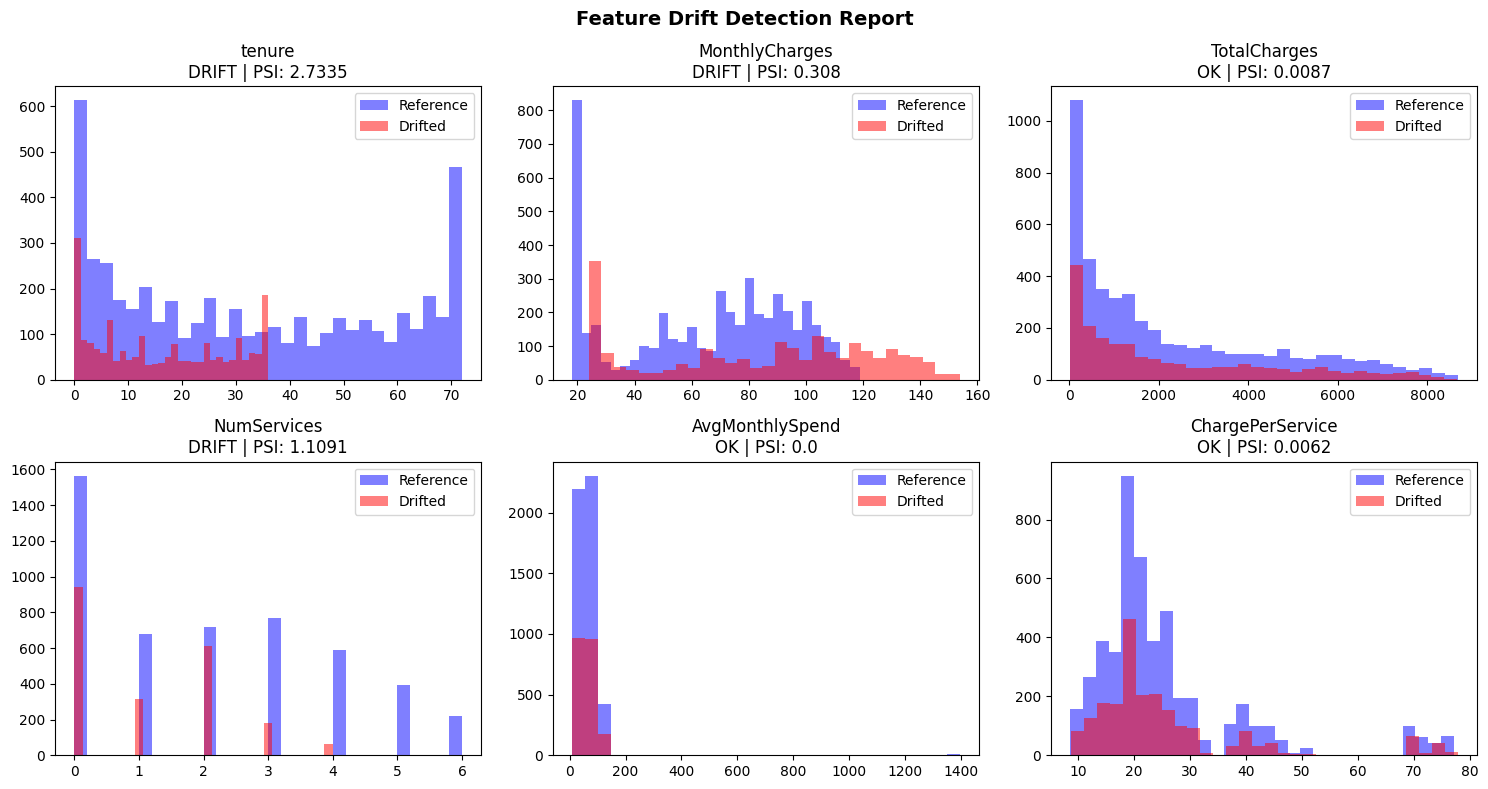

Drift visualization saved!


In [7]:
# Visualize drift results
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].hist(reference_data[feature], bins=30, 
                 alpha=0.5, color='blue', label='Reference')
    axes[i].hist(current_data_drift[feature], bins=30,
                 alpha=0.5, color='red', label='Drifted')
    
    result = drift_results[feature]
    status = "DRIFT" if result['drift_detected'] else "OK"
    axes[i].set_title(f"{feature}\n{status} | PSI: {result['psi']}")
    axes[i].legend()

plt.suptitle('Feature Drift Detection Report', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/drift_visualization.png', dpi=150)
plt.show()
print("Drift visualization saved!")